In [1]:
import pandas as pd

CSV_PATH = "CEN-hist_gen_de_energia_por_central_16_19.csv"

df = pd.read_csv(
    CSV_PATH,
    sep=";",            # ya detectado
    encoding="latin-1", # ya detectado
    decimal=",",        # <-- CLAVE: coma decimal
    thousands=".",      # por si hay miles con punto
    low_memory=False
)

# Fecha
df["FECHA"] = pd.to_datetime(df["FECHA"], dayfirst=True, errors="coerce")

# Lista de columnas de horas
hour_cols = [c for c in df.columns if c.upper().startswith("HORA ")]
df[hour_cols].head(3)

,HORA 1,HORA 2,HORA 3,HORA 4,HORA 5,HORA 6,HORA 7,HORA 8,HORA 9,HORA 10,...,HORA 16,HORA 17,HORA 18,HORA 19,HORA 20,HORA 21,HORA 22,HORA 23,HORA 24,HORA 25
0,1.3,0.6,0.1,1.3,0.0,0.2,0.2,0.0,0.4,0.4,...,1.1,0.3,0.2,1.0,0.7,0.8,0.0,0.3,0.0,NaN
1,0.2,0.0,0.3,0.4,0.2,0.4,0.2,0.7,0.4,0.0,...,0.1,0.2,0.2,1.9,0.1,1.2,0.3,1.3,0.9,NaN
2,0.4,0.2,0.2,0.8,0.0,0.2,1.0,0.2,2.1,0.9,...,0.0,0.2,1.3,0.1,0.2,1.8,0.0,1.7,0.2,NaN


In [18]:
# %%
import pandas as pd
import numpy as np

plant_col = "NOMBRE CENTRAL"
date_col  = "FECHA"
hour_cols = [c for c in df.columns if str(c).upper().startswith("HORA ")]

# Asegúrate de no incluir HORA 25 si querés 24 filas por día:
hour_cols = [c for c in hour_cols if c != "HORA 25"]

# --- 1) Crudo (una fila = un día por central) ---
n_raw = len(df)
print("[RAW] filas:", n_raw)

# --- 2) Largo (una fila = (fecha, central, hora)) ---
df_min = df[[date_col, plant_col] + hour_cols].copy()
for c in hour_cols:
    df_min[c] = pd.to_numeric(df_min[c], errors="coerce")

long_df = df_min.melt(
    id_vars=[date_col, plant_col],
    value_vars=hour_cols,
    var_name="col_hora",
    value_name="energia"
)
long_df["hora_num"] = long_df["col_hora"].str.extract(r"(\d+)$").astype(int) - 1
long_df["timestamp"] = pd.to_datetime(long_df[date_col]) + pd.to_timedelta(long_df["hora_num"], unit="h")

n_long = len(long_df)
print("[LONG] filas (pares timestamp-central):", n_long)

# --- 3) Agregado por (timestamp, central) y pivot ---
agg = long_df.groupby(["timestamp", plant_col], as_index=False)["energia"].sum(min_count=1)
n_pairs = len(agg)
print("[AGG] filas (pares únicos timestamp-central):", n_pairs)

wide = agg.pivot(index="timestamp", columns=plant_col, values="energia").sort_index()

n_wide_rows = len(wide)
n_wide_cols = wide.shape[1]
print("[WIDE] filas (timestamps únicos):", n_wide_rows)
print("[WIDE] columnas (centrales):", n_wide_cols)

print("\nRango:", wide.index.min(), "→", wide.index.max())

# Estimación teórica de horas entre min y max (para sanity check)
expected_hours = pd.date_range(wide.index.min(), wide.index.max(), freq="H").size
print("Horas esperadas por rango continuo:", expected_hours)

# Relación: cuántas centrales (promedio) tienen dato por timestamp
# (si hubiera datos completos, ~ n_wide_cols)
avg_centrales_por_ts = n_pairs / max(n_wide_rows, 1)
print("Promedio de 'centrales con dato' por timestamp:", round(avg_centrales_por_ts, 2))


[RAW] filas: 897755
[LONG] filas (pares timestamp-central): 21546120
[AGG] filas (pares únicos timestamp-central): 14964288
[WIDE] filas (timestamps únicos): 35064
[WIDE] columnas (centrales): 550

Rango: 2016-01-01 00:00:00 → 2019-12-31 23:00:00
Horas esperadas por rango continuo: 35064
Promedio de 'centrales con dato' por timestamp: 426.77


C:\Users\Abduzcan0\AppData\Local\Temp\ipykernel_25176\592917698.py:48: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  expected_hours = pd.date_range(wide.index.min(), wide.index.max(), freq="H").size


In [3]:
df

,NOMBRE CENTRAL,LLAVE NOMBRE,TIPO,SUBTIPO,REGIÓN,ernc/convencional,Factor ERNC,FECHA,HORA 1,HORA 2,...,HORA 17,HORA 18,HORA 19,HORA 20,HORA 21,HORA 22,HORA 23,HORA 24,HORA 25,TOTAL
0,BESS Andes,BESS Andes,Bess,NaN,Región de Antofagasta,convencional,0.0,2016-01-01,1.3,0.6,...,0.3,0.2,1.0,0.7,0.8,0.0,0.3,0.0,NaN,11.3
1,BESS Andes,BESS Andes,Bess,NaN,Región de Antofagasta,convencional,0.0,2016-01-02,0.2,0.0,...,0.2,0.2,1.9,0.1,1.2,0.3,1.3,0.9,NaN,10.0
2,BESS Andes,BESS Andes,Bess,NaN,Región de Antofagasta,convencional,0.0,2016-01-03,0.4,0.2,...,0.2,1.3,0.1,0.2,1.8,0.0,1.7,0.2,NaN,13.1
3,BESS Andes,BESS Andes,Bess,NaN,Región de Antofagasta,convencional,0.0,2016-01-04,0.2,1.0,...,0.0,1.7,1.0,0.6,1.6,0.1,0.0,0.0,NaN,12.4
4,BESS Andes,BESS Andes,Bess,NaN,Región de Antofagasta,convencional,0.0,2016-01-05,0.0,0.0,...,0.0,0.0,1.4,0.1,0.0,0.0,1.5,0.0,NaN,4.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
897750,TER YUNGAY,Yungay 1 Diésel,Térmica,Diésel,Región del Bío-Bío,convencional,0.0,2019-12-31,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
897751,TER YUNGAY,Yungay 2 Diésel,Térmica,Diésel,Región del Bío-Bío,convencional,0.0,2019-12-31,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
897752,TER YUNGAY,Yungay 2 GNL,Térmica,Gas Natural,Región del Bío-Bío,convencional,0.0,2019-12-31,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
897753,TER YUNGAY,Yungay 1 GNL,Térmica,Gas Natural,Región del Bío-Bío,convencional,0.0,2019-12-31,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0


In [19]:
# %%
import pandas as pd
import numpy as np

plant_col = "NOMBRE CENTRAL"
date_col  = "FECHA"
hour_cols = [c for c in df.columns if str(c).upper().startswith("HORA ")]

# 1) descartar HORA 25 si existe (queremos 24 filas por día)
hour_cols = [c for c in hour_cols if c != "HORA 25"]

# 2) asegurar numérico en horas (por si quedó texto)
for c in hour_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 3) quedarnos solo con fecha, central y horas (sin tocar df original)
df_min = df[[date_col, plant_col] + hour_cols].copy()

# 4) pasar a formato largo: una fila por (fecha, central, hora)
long_df = df_min.melt(
    id_vars=[date_col, plant_col],
    value_vars=hour_cols,
    var_name="col_hora",
    value_name="energia"
)

# 5) extraer número de hora (1..24) y llevarlo a 0..23 para sumar a la fecha
long_df["hora_num"] = long_df["col_hora"].str.extract(r"(\d+)$").astype(int) - 1

# 6) timestamp = FECHA + hora_num horas
long_df["timestamp"] = pd.to_datetime(long_df[date_col]) + pd.to_timedelta(long_df["hora_num"], unit="h")

# 7) si hay duplicados para el mismo (timestamp, central), los sumamos
agg = (
    long_df.groupby(["timestamp", plant_col], as_index=False)["energia"]
           .sum(min_count=1)  # deja NaN si todas eran NaN
)

# 8) pivot -> filas = timestamp horario, columnas = centrales
wide = agg.pivot(index="timestamp", columns=plant_col, values="energia").sort_index()

wide


NOMBRE CENTRAL,BESS Andes,BESS Angamos,BESS Cochrane,CERRO DOMINADOR,GEO CERRO PABELLON,HE ANGOSTURA,HE ANTUCO,HE CANUTILLAR,HE CIPRESES,HE COLBUN,...,TER TERMOPACIFICO,TER TOCOPILLA,TER TRAPEN,TER TRINCAO,TER UJINA,TER VALDIVIA,TER VENTANAS,TER VENTANAS II,TER VIÑALES,TER YUNGAY
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,1.3,1.7,NaN,NaN,NaN,47.0,161.0,56.0,102.0,3.0,...,0.0,538.3,0.0,0.0,NaN,45.3,70.0,146.0,28.0,0.0
2016-01-01 01:00:00,0.6,0.2,NaN,NaN,NaN,47.0,161.0,15.0,102.0,0.0,...,0.0,579.8,0.0,0.0,NaN,50.8,70.0,145.0,28.0,0.0
2016-01-01 02:00:00,0.1,0.0,NaN,NaN,NaN,47.0,161.0,0.0,102.0,0.0,...,0.0,574.3,0.0,0.0,NaN,44.0,71.0,141.0,28.1,0.0
2016-01-01 03:00:00,1.3,1.7,NaN,NaN,NaN,47.0,161.0,0.0,99.0,0.0,...,0.0,576.4,0.0,0.0,NaN,46.5,71.0,145.0,28.0,0.0
2016-01-01 04:00:00,0.0,0.0,NaN,NaN,NaN,65.0,161.0,0.0,102.0,0.0,...,0.0,588.1,0.0,0.0,NaN,46.5,71.0,143.0,28.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-31 19:00:00,0.4,0.3,0.0,NaN,26.3,57.0,160.0,0.0,45.0,113.0,...,0.0,NaN,0.0,0.0,NaN,27.2,0.0,92.0,22.2,0.0
2019-12-31 20:00:00,0.4,0.3,0.0,NaN,27.1,47.0,160.0,0.0,54.0,185.0,...,0.0,NaN,0.0,0.0,NaN,23.7,0.0,97.0,22.4,0.0
2019-12-31 21:00:00,0.4,0.3,0.0,NaN,27.7,47.0,160.0,0.0,60.0,265.0,...,0.0,NaN,0.0,0.0,NaN,28.0,0.0,129.0,27.1,0.0


In [20]:
# %%
full_index = pd.date_range(wide.index.min(), wide.index.max(), freq="H")
wide = wide.reindex(full_index)
wide.index.name = "timestamp"
wide


C:\Users\Abduzcan0\AppData\Local\Temp\ipykernel_25176\3312596469.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_index = pd.date_range(wide.index.min(), wide.index.max(), freq="H")


NOMBRE CENTRAL,BESS Andes,BESS Angamos,BESS Cochrane,CERRO DOMINADOR,GEO CERRO PABELLON,HE ANGOSTURA,HE ANTUCO,HE CANUTILLAR,HE CIPRESES,HE COLBUN,...,TER TERMOPACIFICO,TER TOCOPILLA,TER TRAPEN,TER TRINCAO,TER UJINA,TER VALDIVIA,TER VENTANAS,TER VENTANAS II,TER VIÑALES,TER YUNGAY
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,1.3,1.7,NaN,NaN,NaN,47.0,161.0,56.0,102.0,3.0,...,0.0,538.3,0.0,0.0,NaN,45.3,70.0,146.0,28.0,0.0
2016-01-01 01:00:00,0.6,0.2,NaN,NaN,NaN,47.0,161.0,15.0,102.0,0.0,...,0.0,579.8,0.0,0.0,NaN,50.8,70.0,145.0,28.0,0.0
2016-01-01 02:00:00,0.1,0.0,NaN,NaN,NaN,47.0,161.0,0.0,102.0,0.0,...,0.0,574.3,0.0,0.0,NaN,44.0,71.0,141.0,28.1,0.0
2016-01-01 03:00:00,1.3,1.7,NaN,NaN,NaN,47.0,161.0,0.0,99.0,0.0,...,0.0,576.4,0.0,0.0,NaN,46.5,71.0,145.0,28.0,0.0
2016-01-01 04:00:00,0.0,0.0,NaN,NaN,NaN,65.0,161.0,0.0,102.0,0.0,...,0.0,588.1,0.0,0.0,NaN,46.5,71.0,143.0,28.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-31 19:00:00,0.4,0.3,0.0,NaN,26.3,57.0,160.0,0.0,45.0,113.0,...,0.0,NaN,0.0,0.0,NaN,27.2,0.0,92.0,22.2,0.0
2019-12-31 20:00:00,0.4,0.3,0.0,NaN,27.1,47.0,160.0,0.0,54.0,185.0,...,0.0,NaN,0.0,0.0,NaN,23.7,0.0,97.0,22.4,0.0
2019-12-31 21:00:00,0.4,0.3,0.0,NaN,27.7,47.0,160.0,0.0,60.0,265.0,...,0.0,NaN,0.0,0.0,NaN,28.0,0.0,129.0,27.1,0.0


In [21]:
# %%
wide.to_csv("energia_timeseries_matrix.csv")
print("OK -> energia_timeseries_matrix.[parquet|csv]")


OK -> energia_timeseries_matrix.[parquet|csv]


In [7]:
#leer csv
import pandas as pd

wide = pd.read_csv("energia_timeseries_matrix.csv", index_col=0, parse_dates=True)
wide

,BESS Andes,BESS Angamos,BESS Cochrane,CERRO DOMINADOR,GEO CERRO PABELLON,HE ANGOSTURA,HE ANTUCO,HE CANUTILLAR,HE CIPRESES,HE COLBUN,...,TER TERMOPACIFICO,TER TOCOPILLA,TER TRAPEN,TER TRINCAO,TER UJINA,TER VALDIVIA,TER VENTANAS,TER VENTANAS II,TER VIÑALES,TER YUNGAY
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,1.3,1.7,NaN,NaN,NaN,47.0,161.0,56.0,102.0,3.0,...,0.0,538.3,0.0,0.0,NaN,45.3,70.0,146.0,28.0,0.0
2016-01-01 01:00:00,0.6,0.2,NaN,NaN,NaN,47.0,161.0,15.0,102.0,0.0,...,0.0,579.8,0.0,0.0,NaN,50.8,70.0,145.0,28.0,0.0
2016-01-01 02:00:00,0.1,0.0,NaN,NaN,NaN,47.0,161.0,0.0,102.0,0.0,...,0.0,574.3,0.0,0.0,NaN,44.0,71.0,141.0,28.1,0.0
2016-01-01 03:00:00,1.3,1.7,NaN,NaN,NaN,47.0,161.0,0.0,99.0,0.0,...,0.0,576.4,0.0,0.0,NaN,46.5,71.0,145.0,28.0,0.0
2016-01-01 04:00:00,0.0,0.0,NaN,NaN,NaN,65.0,161.0,0.0,102.0,0.0,...,0.0,588.1,0.0,0.0,NaN,46.5,71.0,143.0,28.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-31 19:00:00,0.4,0.3,0.0,NaN,26.3,57.0,160.0,0.0,45.0,113.0,...,0.0,NaN,0.0,0.0,NaN,27.2,0.0,92.0,22.2,0.0
2019-12-31 20:00:00,0.4,0.3,0.0,NaN,27.1,47.0,160.0,0.0,54.0,185.0,...,0.0,NaN,0.0,0.0,NaN,23.7,0.0,97.0,22.4,0.0
2019-12-31 21:00:00,0.4,0.3,0.0,NaN,27.7,47.0,160.0,0.0,60.0,265.0,...,0.0,NaN,0.0,0.0,NaN,28.0,0.0,129.0,27.1,0.0


In [8]:
#ver cantidad de datos por columna
wide.info()
#ver nulos por columna
wide.isnull().sum()
#top 3 con menos datos nulos 
wide.isnull().sum().sort_values().head(3)



<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35064 entries, 2016-01-01 00:00:00 to 2019-12-31 23:00:00
Columns: 550 entries, BESS Andes to TER YUNGAY
dtypes: float64(550)
memory usage: 147.4 MB


TER YUNGAY                        0
PMGD HP EL LLANO                  0
PMGD HP EL MANZANO (MELIPEUCO)    0
dtype: int64

In [9]:
#top 3 con menos datos nulos guardar las columnas de los 3 con menos datos nulos
top3_menos_nulos = wide.isnull().sum().sort_values(ascending=True).head(3)
top3_menos_nulos = top3_menos_nulos.index.tolist()
top3_menos_nulos
#guardar las columnas de los 3 con menos datos nulos en un nuevo dataframe
top3_menos_nulos_df = wide[top3_menos_nulos]

In [10]:
top3_menos_nulos_df
#guardar csv
top3_menos_nulos_df.to_csv("top3_menos_nulos.csv")

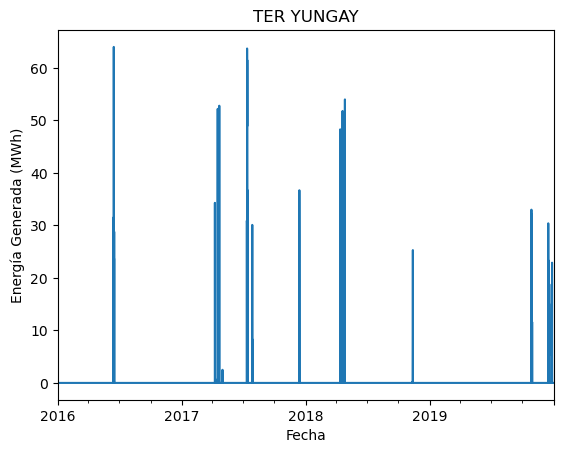

In [11]:
#graficar 1 columna "TER YUNGAY"
import matplotlib.pyplot as plt
top3_menos_nulos_df["TER YUNGAY"].plot()
plt.title("TER YUNGAY")
plt.xlabel("Fecha")
plt.ylabel("Energía Generada (MWh)")
plt.show()


In [17]:
#graficar 2 columna PMGD HP EL LLANO
import matplotlib.pyplot as plt
top3_menos_nulos_df["PMGD HP EL MANZANO (MELIPEUCO)"].plot()
plt.title("PMGD HP EL MANZANO (MELIPEUCO)")
plt.xlabel("Fecha")
plt.ylabel("Energía Generada (MWh)")
plt.show()


KeyError: 'PMGD HP EL MANZANO (MELIPEUCO)'

In [12]:
#del dataset original tomar los 3 con menos nulos y menos distintos de 0

#top 3 con menos datos nulos guardar las columnas de los 3 con menos datos nulos y menos distintos de 0
top3_menos_nulos = wide.isnull().sum().sort_values(ascending=True)
top3_menos_nulos = top3_menos_nulos.index.tolist()
top3_menos_nulos
top3_menos_nulos_df = wide[top3_menos_nulos]
top3_menos_nulos_df = top3_menos_nulos_df[top3_menos_nulos_df.nunique().sort_values().head(3).index]
top3_menos_nulos_df

,TER SALTA [NO_MOSTRAR],CERRO DOMINADOR,TER ENAEX [NO_MOSTRAR]
timestamp,,,
2016-01-01 00:00:00,NaN,NaN,NaN
2016-01-01 01:00:00,NaN,NaN,NaN
2016-01-01 02:00:00,NaN,NaN,NaN
2016-01-01 03:00:00,NaN,NaN,NaN
2016-01-01 04:00:00,NaN,NaN,NaN
...,...,...,...
2019-12-31 19:00:00,NaN,NaN,NaN
2019-12-31 20:00:00,NaN,NaN,NaN
2019-12-31 21:00:00,NaN,NaN,NaN


In [6]:
import pandas as pd

#leer csv weather.csv
weather_df = pd.read_csv("weather.csv", index_col=0, parse_dates=True)
weather_df
#solo guardar columna T (degC) 
weather_df = weather_df[["T (degC)"]]
weather_df

,T (degC)
date,
2020-01-01 00:10:00,0.71
2020-01-01 00:20:00,0.75
2020-01-01 00:30:00,0.73
2020-01-01 00:40:00,0.37
2020-01-01 00:50:00,0.33
...,...
2020-12-31 23:20:00,2.28
2020-12-31 23:30:00,2.13
2020-12-31 23:40:00,1.99


In [7]:
#mostratr ultimos 500 filas
weather_df.tail(500)
weather_df

,T (degC)
date,
2020-01-01 00:10:00,0.71
2020-01-01 00:20:00,0.75
2020-01-01 00:30:00,0.73
2020-01-01 00:40:00,0.37
2020-01-01 00:50:00,0.33
...,...
2020-12-31 23:20:00,2.28
2020-12-31 23:30:00,2.13
2020-12-31 23:40:00,1.99
